#
# <center> Retail-Weather Dataset Data Mining Project Phase 1 - Spring 2026
## <center> Created By: Saba Berenji & Sierra Erb

# Problem Statement

Online store sales can change day to day and this can make it tough for managers to plan accordingly for actions such as invectory management or how many staff members are required to be scheduled. Most stores only look at past sales to guess future demand and they ignore short-term factors such as daily weather (https://www.sciencedirect.com/science/article/abs/pii/S0969698919303236 ). Weather can directly affect the way people shop. For instance bad weather can keep people indoors, leading them to buy online instead of visiting physical stores. Studies show that weather causes around 3.4% of sales shifts across the economy (Lazo,2011), but we still do not fully understand how it impacts individual online shopping day by day.

This project uses real sales and weather data from a UK online retailer to solve this problem. It looks at three main things: which products customers usually buy together, how daily weather changes customer behaviour, and how to group similar sales days based on weather patterns. The goal is to give the retailer a simple, weather-informed way to plan inventory and staffing more accurately.


# Data Collection

This project uses two datasets collected from Kaggle. Dataset 1 is a real online retailer transactions from multiple countries from Dec 2009 - Dec 2011 (https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) with 1,067,371 records and 8 columns. The second dataset is real UK weather observations across 504 locations from 2009 - 20014 https://www.kaggle.com/datasets/jakewright/2m-daily-weather-history-uk) with 1,048,575 records and 10 columns. The first dataset is used to get the online retail transactions for a UK retailer, which combined with the second daily national weather dataset, can help answer the question of how does the weather condition affect sales in this store.

# Descriptive Summary

Two datasets are used in this project. Dataset 1 is a real online retailer transactions from multiple countries from Dec 2009 - Dec 2011 (https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) with 1,067,371 records and 8 columns. The eight columns include features such as invoice, stock code, description, quantity, invoice date, price, customer, and country. 24.24% of rows have missing customer IDs; several unit prices are less than 0, which is invalid; and several quantity values are negative, indicating returns or cancelled orders. 3.43% of rows are duplicates and were removed. The second dataset is real UK weather observations across 504 locations from 2009 - 20014 https://www.kaggle.com/datasets/jakewright/2m-daily-weather-history-uk) with 1,048,575 records and 10 columns. The ten columns include features such as location, date, average min temp, average max temp, rain, humidity %, cloud coverage %, and wind speed. There are no missing values in the weather dataset and no duplicate rows. Several outliers were identified in both datasets; they were deemed valid and therefore not removed. The numerical variables were discretized into several bins using quantile binning or equal-width binning, depending on the distribution.


# Installing and importing libraries and packages

In [ ]:
# Installing the required libraries
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import getpass
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Read Data from Data Warehouse and Load Into Dataframe

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
A relational Data Warehouse was built in MySQL using a star schema design as a first step of this project. First the two datasets, online retail and wheater datasets, were loaded into MySQL. The retails table was broken down into two tables. At the core of the retail star schema is the fact_sales table which stores transactional items including quantities, unit prices, and a generated 'total_amount' field. To preserve complete transaction history (especially for possible customers that did not have an ID) the customer data was also included in the same table. The fact table links to the 'dim_product' table through a foreign key. <br>
    <br> During the ETL process, the data and time from the original online retail dataset that appeared in the same column were separated and represented as separate attributes and missing customer IDs were converted to NULL values. Additionally to handle product description in the dim_product table so it won't get overwritten with false descriptions, a cleaning was done to ensure that the descriptions were the correct description of the data. In this step we used temporary look up tables, we selected the most frequently occurring uppercase description as the primary choice, using the most common non-null description as a fallback. This ensured each product code was assigned its single best catalog name in dim_product. Lastly, the weather data was loaded into the uk_weather table but not connected to the fact table.
    
</div>

![image.png](attachment:b51b2423-93b5-4a17-b823-4dd7d9848f8a.png)

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The dataset has been loaded to the local MySQL server and in order to execute SQL queries directly against the database, a connection is established with the MySQL server that has the 'retail_weather_analysis' schema.
</div>

In [ ]:
# Define Database Connection Parameters
USER = 'root'            #  MySQL username
HOST = 'localhost'       # MySQL server host
PORT = '3306'            # Default MySQL port
DATABASE = 'retail_weather' # Schema name
# Using 'getpass' for security purposes of not sharing password
PASSWORD = getpass.getpass('Enter MySQL Password: ')

# Create SQLAlchemy Engine
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")


Enter MySQL Password:  ········


In [ ]:
# Load data into a Pandas DataFrame
fact_df = pd.read_sql("SELECT * FROM fact_sales;", engine)
product_df = pd.read_sql("SELECT * FROM dim_product;", engine)
weather_df = pd.read_sql("SELECT * FROM uk_weather;", engine)

In [ ]:
# Print the shape of the datafrrames
print(f"Shape of df_fact: {fact_df.shape}")
print(f"Shape of df_product: {product_df.shape}")
print(f"Shape of df_weather: {weather_df.shape}")

Shape of df_fact: (1048575, 10)
Shape of df_product: (5131, 2)
Shape of df_weather: (1048575, 11)


In [ ]:
# Printing the first 5 rows of fact_df
fact_df.head()

,sales_record_id,invoice_id,product_code,customer_id,country,invoice_date,invoice_time,quantity,unit_price,total_amount
0,1,489434,85048,13085.0,United Kingdom,2009-12-01,0 days 07:45:00,12,6.95,83.4
1,2,489434,79323P,13085.0,United Kingdom,2009-12-01,0 days 07:45:00,12,6.75,81.0
2,3,489434,79323W,13085.0,United Kingdom,2009-12-01,0 days 07:45:00,12,6.75,81.0
3,4,489434,22041,13085.0,United Kingdom,2009-12-01,0 days 07:45:00,48,2.10,100.8
4,5,489434,21232,13085.0,United Kingdom,2009-12-01,0 days 07:45:00,24,1.25,30.0


In [ ]:
# Printing the first 5 rows of product_df
product_df.head()

,product_code,product_description
0,10002,INFLATABLE POLITICAL GLOBE
1,10002R,ROBOT PENCIL SHARPNER
2,10080,GROOVY CACTUS INFLATABLE
3,10109,BENDY COLOUR PENCILS
4,10120,DOGGY RUBBER


In [ ]:
# Printing the first 5 rows weather_df
weather_df.head()

,weather_record_id,location,weather_date,min_temp_c,max_temp_c,rain_mm,humidity_pct,cloud_cover_pct,wind_speed_kmh,wind_direction,wind_direction_degrees
0,1,Holywood,2009-01-01,0,3,0.0,86,14,12,E,90.0
1,2,North Cray,2009-01-01,-3,2,0.0,93,44,8,NNE,22.5
2,3,Portknockie,2009-01-01,2,4,0.8,88,87,10,ESE,112.5
3,4,Blairskaith,2009-01-01,-3,1,0.0,86,43,12,ENE,67.5
4,5,Onehouse,2009-01-01,-1,3,0.0,91,63,7,S,180.0


In [ ]:
# Since the problem statement is focused on UK, we filter for this country only and save the data in a new dataframe
uk_fact_df = df_fact[df_fact["country"] == "United Kingdom"].copy()

In [ ]:
print("Original rows:", len(fact_df))
print("UK rows:", len(uk_fact_df))

Original rows: 1048575
UK rows: 963819


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, out of around 1 million samples in this dataset, more than 900K rows belong to UK, which makes it the majority of the dataset.
</div>

In [ ]:
# Print the attributes for each table
print("Number of attributes:", uk_fact_df.shape[1])

print("\nColumn names:")
for number, column in enumerate(uk_fact_df.columns, start=1):
    print(f"{number}. {column}")

Number of attributes: 10

Column names:
1. sales_record_id
2. invoice_id
3. product_code
4. customer_id
5. country
6. invoice_date
7. invoice_time
8. quantity
9. unit_price
10. total_amount


In [ ]:
# Print the attributes for each table
print("Number of attributes for fact table:", product_df.shape[1])

print("\nColumn names:")
for number, column in enumerate(product_df.columns, start=1):
    print(f"{number}. {column}")

Number of attributes for fact table: 2

Column names:
1. product_code
2. product_description


In [ ]:
# Print the attributes for each table
print("Number of attributes for the product table:", weather_df.shape[1])

print("\nColumn names:")
for number, column in enumerate(weather_df.columns, start=1):
    print(f"{number}. {column}")

Number of attributes for the product table: 11

Column names:
1. weather_record_id
2. location
3. weather_date
4. min_temp_c
5. max_temp_c
6. rain_mm
7. humidity_pct
8. cloud_cover_pct
9. wind_speed_kmh
10. wind_direction
11. wind_direction_degrees


In [ ]:
# Print the information of uk_fact_df (such as the datatypes)
uk_fact_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 963819 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype          
---  ------           --------------   -----          
 0   sales_record_id  963819 non-null  int64          
 1   invoice_id       963819 non-null  object         
 2   product_code     963819 non-null  object         
 3   customer_id      730115 non-null  float64        
 4   country          963819 non-null  object         
 5   invoice_date     963819 non-null  object         
 6   invoice_time     963819 non-null  timedelta64[ns]
 7   quantity         963819 non-null  int64          
 8   unit_price       963819 non-null  float64        
 9   total_amount     963819 non-null  float64        
dtypes: float64(3), int64(2), object(4), timedelta64[ns](1)
memory usage: 80.9+ MB


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
We can see that the data type for the invoice_time attribute is 'timedelta64'. On the other hand, when printing the first 5 columns of the dataframe earlier, we saw that there are values such as '0 days 07:45:00'. This is because in MySQL, the TIME data type (which is the data type that we used for this attribute), stores a duration. When Pandas reads a MySQL TIME column  using read_sql(), it turns it into a timedelta64[ns] object instead of a string or time object. Since this data type measures a duration (e.g. 0 days 07:45:00), Pandas diaplays the 0 days prefix by default. We will handle this issue later on.
</div>

In [ ]:
# Print the information of product_df (such as the datatypes)
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5131 entries, 0 to 5130
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_code         5131 non-null   object
 1   product_description  4778 non-null   object
dtypes: object(2)
memory usage: 80.3+ KB


In [ ]:
# Print the information of weather_df (such as the datatypes)
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   weather_record_id       1048575 non-null  int64  
 1   location                1048575 non-null  object 
 2   weather_date            1048575 non-null  object 
 3   min_temp_c              1048575 non-null  int64  
 4   max_temp_c              1048575 non-null  int64  
 5   rain_mm                 1048575 non-null  float64
 6   humidity_pct            1048575 non-null  int64  
 7   cloud_cover_pct         1048575 non-null  int64  
 8   wind_speed_kmh          1048575 non-null  int64  
 9   wind_direction          1048575 non-null  object 
 10  wind_direction_degrees  1048575 non-null  float64
dtypes: float64(2), int64(6), object(3)
memory usage: 88.0+ MB


In [ ]:
# Describe the uk_fact_df dataframe to get statistical data such as mean, minimum value, etc.
uk_fact_df.describe()

,sales_record_id,customer_id,invoice_time,quantity,unit_price,total_amount
count,9.638190e+05,730115.000000,963819,963819.000000,963819.000000,963819.000000
mean,5.222632e+05,15554.322104,0 days 13:36:38.937227840,8.868902,4.510297,16.710191
std,3.031760e+05,1593.438378,0 days 02:23:54.209814591,129.273914,125.924332,184.435055
min,1.000000e+00,12346.000000,0 days 06:10:00,-74215.000000,-53594.360000,-77183.600000
25%,2.594775e+05,14206.000000,0 days 11:51:00,1.000000,1.250000,3.360000
50%,5.211340e+05,15555.000000,0 days 13:34:00,3.000000,2.100000,8.470000
75%,7.833995e+05,16935.000000,0 days 15:26:00,10.000000,4.150000,16.950000
max,1.048575e+06,18287.000000,0 days 21:52:00,74215.000000,38970.000000,77183.600000


In [ ]:
# Describe the product_df dataframe to get statistical data such as mean, minimum value, etc.
product_df.describe()

,product_code,product_description
count,5131,4778
unique,5131,4736
top,10002,COLUMBIAN CANDLE ROUND
freq,1,4


In [ ]:
# Describe the weather_df dataframe to get statistical data such as mean, minimum value, etc.
weather_df.describe()

,weather_record_id,min_temp_c,max_temp_c,rain_mm,humidity_pct,cloud_cover_pct,wind_speed_kmh,wind_direction_degrees
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.242880e+05,6.619404e+00,1.283337e+01,2.385771e+00,8.494077e+01,5.377714e+01,1.546304e+01,1.963339e+02
std,3.026977e+05,4.981769e+00,6.017194e+00,4.367873e+00,7.705633e+00,2.454792e+01,6.938286e+00,7.437405e+01
min,1.000000e+00,-2.500000e+01,-2.100000e+01,0.000000e+00,1.800000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,2.621445e+05,3.000000e+00,9.000000e+00,0.000000e+00,8.000000e+01,3.600000e+01,1.000000e+01,1.575000e+02
50%,5.242880e+05,7.000000e+00,1.300000e+01,3.000000e-01,8.600000e+01,5.500000e+01,1.400000e+01,2.025000e+02
75%,7.864315e+05,1.000000e+01,1.700000e+01,3.000000e+00,9.100000e+01,7.300000e+01,1.900000e+01,2.475000e+02
max,1.048575e+06,2.700000e+01,3.900000e+01,9.890000e+01,1.000000e+02,1.000000e+02,5.700000e+01,3.375000e+02


# Data Preparation - Investigate and Handle Missing Values

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
In this step of the project, we will investigate each of the dataframes for not only missing values but also invalid values (values that do not make sense in the dataset such as negative prices or quantities). After identifying the issues, we will then look into what is the best way to handle these missing and invalid data.
</div>

### Investigating Missing Values

In [ ]:
# Identifying if we have missing values in uk_fact_df
print(uk_fact_df.isnull().sum())

sales_record_id         0
invoice_id              0
product_code            0
customer_id        233704
country                 0
invoice_date            0
invoice_time            0
quantity                0
unit_price              0
total_amount            0
dtype: int64


In [ ]:
# Identifying if we have missing values in product_df
print(product_df.isnull().sum())

product_code             0
product_description    353
dtype: int64


In [ ]:
# Identifying if we have missing values in weather_df
print(weather_df.isnull().sum())

weather_record_id         0
location                  0
weather_date              0
min_temp_c                0
max_temp_c                0
rain_mm                   0
humidity_pct              0
cloud_cover_pct           0
wind_speed_kmh            0
wind_direction            0
wind_direction_degrees    0
dtype: int64


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen the isnull() shows 233704 missing values for the customer_id attribute from uk_fact_df dataframe and 353 missing values for product_description attribute for the product_df dataframe, while it shows no missing values for the weather_def dataframe. However, the questions arises that what if there were other indicators in the dataset other than NULL or empty strings that still shows missing values and is not recognized by Pandas? That is why we should look for other signs of missing values to make sure we are not missing anything in any of the datasets. We will then create a function that would replace any of these missing keywords with NaN so the Pandas library can identify it.
</div>

## Standardizing the Missing Values

In [ ]:
# Define common missing keywords
missing_markers = [
    "",
    " ",
    "NONE",
    "None",
    "none",
    "NULL",
    "Null",
    "null",
    "N/A",
    "n/a",
    "NA",
    "na",
    "UNKNOWN",
    "Unknown",
    "unknown"
]

In [ ]:
# Defining a function to convert any common missing value keyword to NaN to help Pandas identify it
def standardize_missing_values(df):
    """
    Convert blank strings and common text-based missing markers to NaN
    """
    cleaned_df = df.copy()

    for column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].map(
            lambda value: (
                np.nan
                if isinstance(value, str)
                and value.strip().lower() in missing_markers
                else value.strip()
                if isinstance(value, str)
                else value
            )
        )

    return cleaned_df

In [ ]:
# Applying the function defined in the previous cell to uk_fact_df
uk_fact_df = standardize_missing_values(uk_fact_df)

In [ ]:
# Applying the function defined in the previous cell to product_df
product_df = standardize_missing_values(product_df)

In [ ]:
# Applying the function defined in the previous cell to weather_df
weather_df = standardize_missing_values(weather_df)

## Rechecking for Missing Values After Standardization

In [ ]:
# Creating a table with missing frequency and percentage for uk_fact_df to determine if we need to drop the columns or not
retail_missing_summary = pd.DataFrame({"Missing Values": uk_fact_df.isnull().sum(),"Missing Percentage": (uk_fact_df.isnull().mean() * 100)})
# Note: the reason we use 'mean()' here to calculate the percentage is that in Pandas, isnull() converts the data
# into True and False where True means the value is missing and False means not missing. So the mean becomes (count of 1s/total number of rows)

retail_missing_summary.sort_values("Missing Percentage",ascending=False)

,Missing Values,Missing Percentage
customer_id,233704,24.247706
sales_record_id,0,0.000000
invoice_id,0,0.000000
product_code,0,0.000000
country,0,0.000000
invoice_date,0,0.000000
invoice_time,0,0.000000
quantity,0,0.000000
unit_price,0,0.000000
total_amount,0,0.000000


In [ ]:
# Creating a table with missing frequency and percentage for product_df to determine if we need to drop the columns or not
product_missing_summary = pd.DataFrame({"Missing Values": product_df.isnull().sum(),"Missing Percentage": (product_df.isnull().mean() * 100)})

product_missing_summary.sort_values("Missing Percentage",ascending=False)

,Missing Values,Missing Percentage
product_description,353,6.879751
product_code,0,0.000000


In [ ]:
# Creating a table with missing frequency and percentage for weather_df to determine if we need to drop the columns or not
weeather_missing_summary = pd.DataFrame({"Missing Values": weather_df.isnull().sum(),"Missing Percentage": (weather_df.isnull().mean() * 100)})

weeather_missing_summary.sort_values("Missing Percentage",ascending=False)

,Missing Values,Missing Percentage
weather_record_id,0,0.0
location,0,0.0
weather_date,0,0.0
min_temp_c,0,0.0
max_temp_c,0,0.0
rain_mm,0,0.0
humidity_pct,0,0.0
cloud_cover_pct,0,0.0
wind_speed_kmh,0,0.0
wind_direction,0,0.0


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, no change was made to any of the dataframes after standardizing. So now we can just proceed with handling the missing values we have identified in uk_fact_df and product_df dataframes.  
</div>

## Handling missing values for customer_id

In [ ]:
# Creating a dataframe containing all rows with missing customer IDs
missing_customer = uk_fact_df.loc[uk_fact_df["customer_id"].isna()]

In [ ]:
missing_customer.head()

,sales_record_id,invoice_id,product_code,customer_id,country,invoice_date,invoice_time,quantity,unit_price,total_amount
263,264,489464,21733,NaN,United Kingdom,2009-12-01,0 days 10:52:00,-96,0.00,0.00
283,284,489463,71477,NaN,United Kingdom,2009-12-01,0 days 10:52:00,-240,0.00,0.00
284,285,489467,85123A,NaN,United Kingdom,2009-12-01,0 days 10:53:00,-192,0.00,0.00
470,471,489521,21646,NaN,United Kingdom,2009-12-01,0 days 11:44:00,-50,0.00,0.00
577,578,489525,85226C,NaN,United Kingdom,2009-12-01,0 days 11:49:00,1,0.55,0.55


In [ ]:
print("Total UK invoices:", uk_fact_df["invoice_id"].nunique())

print("Invoices with missing customer ID:",missing_customer["invoice_id"].nunique())

print("Percentage:",round(missing_customer["invoice_id"].nunique()/ uk_fact_df["invoice_id"].nunique() * 100,2),"%")

Total UK invoices: 48509
Invoices with missing customer ID: 8534
Percentage: 17.59 %


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The customer_id attribute containes missing values in 24.46% of UK transaction records, corresponding to 17.52% of shopping invoices. Because customer identifiers are not required for the study's objectives (weather analysis, transaction analysis, and association rule mining) and cannot be reliably imputed, the attribute will be removed while all transaction records are retained.
</div>

In [ ]:
# Creating a copy of the dataframe to not make any accidental changes on the original datafram\e
uk_fact_df_clean = uk_fact_df.copy()

In [ ]:
# Remove customer_id since it is not required for this project
uk_fact_df_clean = uk_fact_df_clean.drop(columns=["customer_id"])

## Handling missing values for product_description

In [ ]:
# Creating a copy of the dataframe to not make any accidental changes on the original datafram\e
product_df_clean = product_df.copy()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The product_description attribute contains 353 missing values, representing approximately 6.87% of the UK retail transactions (as we saw earlier). Since this attribute is important in understanding the name of the products, we will have to remove records with missing product description. For instance if we impute them with anything like 'Unknown' for instace, when using it for association rule mining we can get something like unknown -> hat, which is not helpful at all.
</div>

In [ ]:
# Filter dim_product for the rows where product_description is missing
missing_products = product_df_clean[product_df_clean['product_description'].isnull()]

# Display the product codes with no description
display(missing_products.head(10))

,product_code,product_description
8,10124C,None
32,15060A,None
55,16065A,None
57,16131,None
58,16132,None
60,16155H,None
61,16156A,None
69,16161N,None
82,16169H,None
88,16195,None


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Since we need product descriptions, we will drop these.
</div>

In [ ]:
# Dropping rows with missing product_description
product_df_clean = product_df_clean.dropna(subset=['product_description'])

In [ ]:
#Rechecking the missing values for product_description
print(product_df_clean.isnull().sum())

product_code           0
product_description    0
dtype: int64


## Investigating and Handling Invalid Values for Unit Price

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Transactions with zero or negative unit prices do not represent real customer purchases. In retail datasets, these records can be mistakes or even related to events like returns which is out of the scope of the project. Therefore, we need to handle these values.
</div>

In [ ]:
# Count the number of zero and less than zero prices
print("Number of prices that are zero or less than zero: ", (uk_fact_df_clean['unit_price'] <= 0).sum())

Number of prices that are zero or less than zero:  6160


In [ ]:
# Summary table showing frequency and percentage of invalid prices (<= 0)
invalid_price_summary = pd.DataFrame({"Invalid Values": [(uk_fact_df_clean['unit_price'] <= 0).sum()],
                                      "Invalid Percentage": [(uk_fact_df_clean['unit_price'] <= 0).mean() * 100]},
                                     index=["unit_price"])

invalid_price_summary

,Invalid Values,Invalid Percentage
unit_price,6160,0.639124


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen these values make up around 0.63% of the dataset which is less than 1% and can be taken out of the dataset without it affecting the size of the dataset.
</div>

In [ ]:
# Drop rows where unit_price is <= 0 (keep only prices > 0)
uk_fact_df_clean = uk_fact_df_clean[uk_fact_df_clean['unit_price'] > 0]

In [ ]:
# Checking again to make sure thay have been dropped as intended
print((uk_fact_df_clean['unit_price'] <= 0).sum())

0


## Investigating and Handling Invalid Values for Quantities

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Negative quantities in this dataset can either be a mistake (since you cannot have a transaction without an item) or can represent product returns or order cancellations. As mentioned before, as this project focuses on analyzing  sales demand and revenue generation, return transactions are out of scope. Removing zero and negative quantities prevents returned items from affecting aspects like order totals, product demand, and transaction counts which we will use to reflect actual customer purchasing behavior. Therefore, these transactions need to be removed from the dataset.
</div>

In [ ]:
# Count the number of zero and less than zero quantities
print("Number of quantities that are zero or less than zero: ", (uk_fact_df_clean['quantity'] <= 0).sum())

Number of quantities that are zero or less than zero:  16466


In [ ]:
# Summary table showing frequency and percentage of invalid prices (<= 0)
invalid_price_summary = pd.DataFrame({"Invalid Values": [(uk_fact_df_clean['quantity'] <= 0).sum()],
                                      "Invalid Percentage": [(uk_fact_df_clean['quantity'] <= 0).mean() * 100]
                                     }, index=["unit_price"])

invalid_price_summary

,Invalid Values,Invalid Percentage
unit_price,16466,1.719401


In [ ]:
# Drop rows where quantity is <= 0 (keep only quantity > 0)
uk_fact_df_clean = uk_fact_df_clean[uk_fact_df_clean['quantity'] > 0]

In [ ]:
# Checking again to make sure it was dropped as expected
print((uk_fact_df_clean['quantity'] <= 0).sum())

0


# Investigate and Handle Duplicate Rows

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
We will not include sales_record_id when checking exact duplicates because it is a primary key. If you include it, no rows will ever appear duplicated as it's unique.
</div>

## Investigate duplicate rows for retail data

In [ ]:
fact_duplicate_columns = [
    "invoice_id",
    "product_code",
    "quantity",
    "invoice_date",
    "invoice_time",
    "unit_price",
    "country"
]

In [ ]:
# Track row counts before dropping
rows_before = len(uk_fact_df_clean)

# Count exact duplicates
duplicate_count = uk_fact_df_clean.duplicated(subset=fact_duplicate_columns).sum()
duplicate_pct = round((duplicate_count / rows_before) * 100, 2)

print(f"Duplicate sales rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_pct}%")

Duplicate sales rows: 32281
Duplicate percentage: 3.43%


In [ ]:
# View sample duplicate rows sorted by invoice and product
duplicate_rows = (uk_fact_df_clean[uk_fact_df_clean.duplicated(subset=fact_duplicate_columns, keep=False)]
    .sort_values(["invoice_id", "product_code", "invoice_date", "invoice_time"])
)

display(duplicate_rows.head(10))

,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount
379,380,489517,21491,United Kingdom,2009-12-01,0 days 11:34:00,1,1.95,1.95
391,392,489517,21491,United Kingdom,2009-12-01,0 days 11:34:00,1,1.95,1.95
365,366,489517,21821,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
386,387,489517,21821,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
363,364,489517,21912,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
371,372,489517,21912,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
394,395,489517,21912,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
362,363,489517,21913,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
385,386,489517,21913,United Kingdom,2009-12-01,0 days 11:34:00,1,3.75,3.75
368,369,489517,22130,United Kingdom,2009-12-01,0 days 11:34:00,6,0.85,5.10


## Handle duplicates for retail data

In [ ]:
# Dropping the duplicate records while keeping the first instance
uk_fact_df_clean = uk_fact_df_clean.drop_duplicates(subset=fact_duplicate_columns, keep="first").copy()

In [ ]:
# Track row counts after dropping
rows_after = len(uk_fact_df_clean)

print("Number of rows BEFORE dropping:", rows_before)
print("Number of rows AFTER dropping:", rows_after)

Number of rows BEFORE dropping: 941193
Number of rows AFTER dropping: 908912


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
32281 duplicate transaction rows were identified and removed based on matching invoice, product code, quantity, date, time, price, and country values. We kept one copy of each record.
</div>

## Investigate duplicate rows for retail product data

In [ ]:
dim_product_duplicate_columns = [
    "product_code",
    "product_description"
]

In [ ]:
# Track row counts before dropping
rows_before_prod = len(product_df_clean)

# Count exact duplicates
prod_dup_count = product_df_clean.duplicated(subset=product_duplicate_cols).sum()
prod_duplicate_pct = round((prod_dup_count / rows_before) * 100, 2)

print(f"Duplicate sales rows: {prod_dup_count}")
print(f"Duplicate percentage: {prod_duplicate_pct}%")

Duplicate sales rows: 1
Duplicate percentage: 0.0%


In [ ]:
# View sample duplicate rows sorted by product code
duplicate_rows = (product_df_clean[product_df_clean.duplicated(subset=dim_product_duplicate_columns, keep=False)]
    .sort_values(["product_code"]))

display(duplicate_rows.head(10))

,product_code,product_description
3298,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG
3299,47503J,SET/3 FLORAL GARDEN TOOLS IN BAG


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
We only have one duplicate value for this table which we can drop.
</div>

## Handle duplicate rows for retail product data

In [ ]:
# Dropping the duplicate records while keeping the first instance
product_df_clean = product_df_clean.drop_duplicates(subset=dim_product_duplicate_columns, keep="first").copy()

In [ ]:
# Track row counts after dropping
rows_after_prod = len(product_df_clean)

print("Number of rows BEFORE dropping:", rows_before_prod)
print("Number of rows AFTER dropping:", rows_after_prod)

Number of rows BEFORE dropping: 4778
Number of rows AFTER dropping: 4777


## Investigate duplicate rows for weather data

In [ ]:
# Same as the retail data, we won't include the unique IDs
weather_duplicate_columns = [
    "location",
    "weather_date",
    "min_temp_c",
    "max_temp_c",
    "rain_mm",
    "humidity_pct",
    "cloud_cover_pct",
    "wind_speed_kmh",
    "wind_direction",
    "wind_direction_degrees"
]

In [ ]:
# Track row counts before dropping
rows_before = len(weather_df)

# Count exact duplicates
duplicate_count = weather_df.duplicated(subset=weather_duplicate_columns).sum()
duplicate_pct = round((duplicate_count / rows_before) * 100, 2)

print(f"Duplicate weather rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_pct}%")

Duplicate weather rows: 0
Duplicate percentage: 0.0%


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
In addition to normal duplicate check, we can also check for any duplicate location+date. This is because we want to make sure the same location on the same date doesn't have different weather measurements. This can happen due to various reasons such as the weather station accidentally recording the weather temperature twice that day with different readings and giving us different values.
</div>

In [ ]:
# Check for multiple records for the same location and date
duplicate_pairs = weather_df.duplicated(subset=['location', 'weather_date'])

print("Location-date combinations with multiple records:", weather_df[duplicate_pairs]['location'].count())

# Display the duplicate rows (if any)
weather_df[duplicate_pairs].sort_values(['location', 'weather_date']).head(20)

Location-date combinations with multiple records: 0


,weather_record_id,location,weather_date,min_temp_c,max_temp_c,rain_mm,humidity_pct,cloud_cover_pct,wind_speed_kmh,wind_direction,wind_direction_degrees


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen there were no two exact rows for the weather dataframe. We also did a second check of one observation per location per date which was done by grouping reocrds on location and weather_date.This second check was necessary because two records may share the same location and date while differing in one or more weather measurements. No duplicate rows were identified for this dataset, therefore, nothing was removed.
</div>

# Outlier Detection

## Retail Dataset

### Skewness

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Skewness measures the shape of the data distribution. Values close to 0 indicate a nearly symmetric distribution, while large positive or negative values indicate skewed data. The skewness of the variables will be used to determine if a parametric method, such as the Z-score, is appropriate for outlier detection or if a non-parametric method, such as the IQR method, should be used.
</div>

In [ ]:
print("Quantity skewness: ", uk_fact_df_clean['quantity'].skew())
print("Unit price skewness:", uk_fact_df_clean['unit_price'].skew())

Quantity skewness:  576.9422109536974
Unit price skewness: 256.0817867484106


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The quantity and unit price variables have skewness values of 576.94 and 256.08. Both of these values indicate positively skewed distributions, with the unit price having an extremely positively right-skewed distribution. The extreme distributions mean that the Z-score-based outlier detection is not appropriate. Therefore, the IQR method will be used to identify outliers.
</div>

### Kurtosis

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Kurtosis indicates the heaviness of the distribution tails and the presence of extreme values. Larger kurtosis values suggest heavier tails and have a greater likelihood of containing outliers than a normal distribution.
</div>

In [ ]:
print("Quantity kurtosis: ", uk_fact_df_clean['quantity'].kurtosis())
print("Unit price kurtosis:", uk_fact_df_clean['unit_price'].kurtosis())

Quantity kurtosis:  452465.4490689312
Unit price kurtosis: 93341.25696020144


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The quantity and unit price variables have kurtosis values of about 452465.44 and 93341.25, respectively. These kurtosis values are extremely large, indicating that the variables have heavy-tailed distributions with many extremely high values. The kurtosis and skewness values indicate that these variables contain significant outliers.
</div>

### Histogram

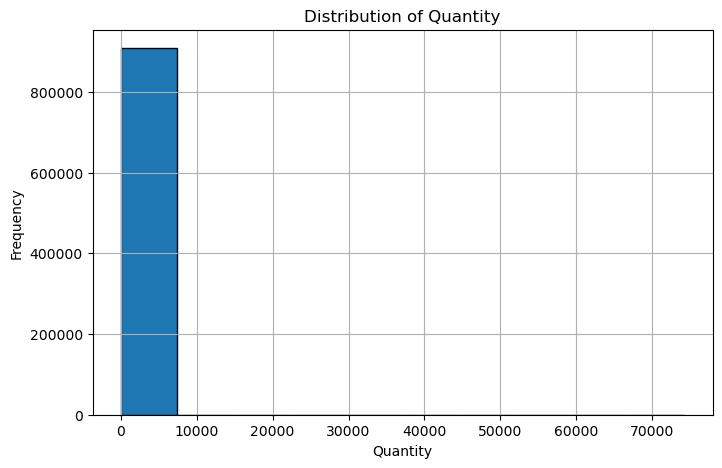

In [ ]:
# Plotting a histogtram to demonstrate the quantity distribution
plt.figure(figsize=(8,5))

uk_fact_df_clean["quantity"].hist(
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As shown in the Distribution of Quantity figure, the quantity variable is strongly positively skewed, with most values between 0 and 10000 and a few extremely high values up to 80000.
</div>

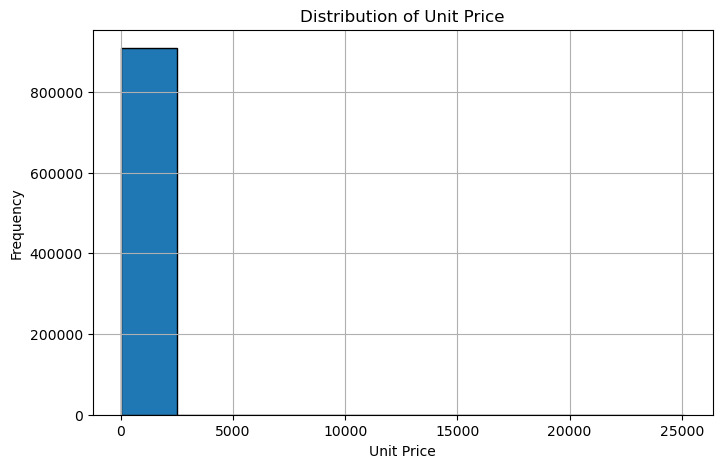

In [ ]:
# Plotting a histogtram to demonstrate the unit price distribution
plt.figure(figsize=(8,5))

uk_fact_df_clean["unit_price"].hist(
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As shown in the Distribution of Unit Price figure, the unit price variable is strongly positively skewed, with most values between 0 and 5000 and a few extremely high values up to 25000.
</div>

#### Boxplot

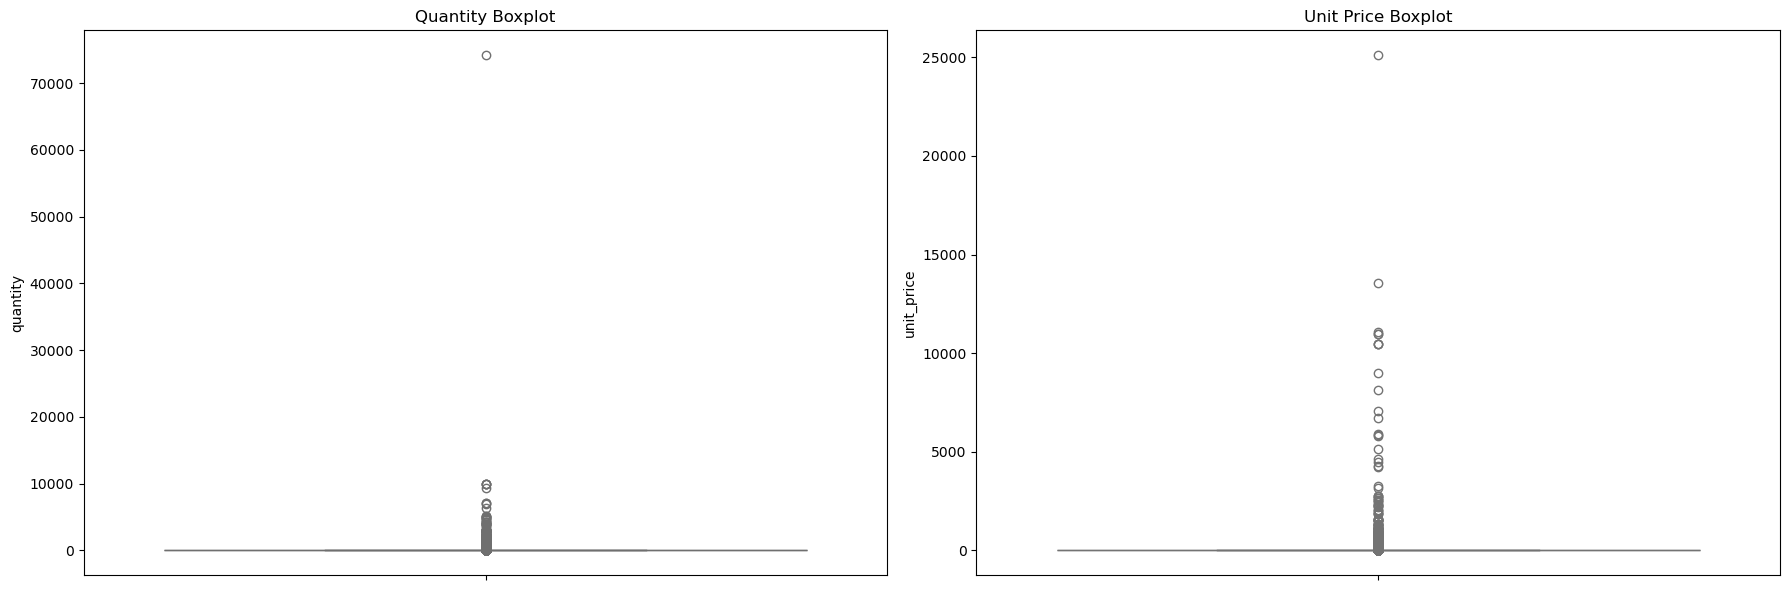

In [ ]:
# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot for budget attribute
sns.boxplot(y=uk_fact_df_clean["quantity"], ax=axes[0], color='skyblue')
axes[0].set_title('Quantity Boxplot')

# Boxplot for revenue attribute
sns.boxplot(y=uk_fact_df_clean["unit_price"], ax=axes[1], color='lightgreen')
axes[1].set_title('Unit Price Boxplot')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As shown in the Quantity and Unit Price Boxplots, there are extreme outliers in both variables. Since the distributions are not normal, we will use the Interquartile Range (IQR) method to detect outliers.
</div>

In [ ]:
# For quantity
Q1 = uk_fact_df_clean["quantity"].quantile(0.25)
Q3 = uk_fact_df_clean["quantity"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

quantity_outliers = uk_fact_df_clean[
    (uk_fact_df_clean["quantity"] < lower) |
    (uk_fact_df_clean["quantity"] > upper)
]

print(quantity_outliers.shape)

(89010, 10)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The IQR method identified 89,010 outliers in the quantity variable. These quantity values are unusually large purchase quantities compared with most other records. These outliers, however, are likely to represent legitimate purchases of item quantities, such as bulk or wholesale orders. As a result, these outliers will not be removed.
</div>

In [ ]:
# For unit price
Q1 = uk_fact_df_clean["unit_price"].quantile(0.25)
Q3 = uk_fact_df_clean["unit_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = uk_fact_df_clean[
    (uk_fact_df_clean["unit_price"] < lower) |
    (uk_fact_df_clean["unit_price"] > upper)
]

print(price_outliers.shape)

(56146, 10)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The IQR method identified 56,146 outliers in the unit price variable. These unit prices are unusually high compared with most other records. These outliers, however, are likely to represent legitimate prices of items, such as premium or specialty items. As a result, these outliers will not be removed.
</div>

## Weather Dataset

### Skewness

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Skewness measures the shape of the data distribution. Values close to 0 indicate a nearly symmetric distribution, while large positive or negative values indicate skewed data. The skewness of the variables will be used to determine if a parametric method, such as the Z-score, is appropriate for outlier detection or if a non-parametric method, such as the IQR method, should be used.
</div>

In [ ]:
print("Min Temp skewness: ", weather_df['min_temp_c'].skew())
print("Max Temp skewness:", weather_df['max_temp_c'].skew())
print("Rain (mm) skewness:", weather_df['rain_mm'].skew())
print("Humidity skewness:", weather_df['humidity_pct'].skew())
print("Cloud cover skewness:", weather_df['cloud_cover_pct'].skew())
print("Wind speed skewness:", weather_df['wind_speed_kmh'].skew())

Min Temp skewness:  -0.16382734703450277
Max Temp skewness: 0.08155265853246274
Rain (mm) skewness: 3.34573461146367
Humidity skewness: -0.826529387675993
Cloud cover skewness: -0.16864200139178
Wind speed skewness: 0.8892704796155376


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The weather variables have substantially lower skewness compared to the retail variables. The min temp, max temp, and cloud cover variables have extremely slight positive skew but are nearly symmetrical. Similarly, the cloud cover variable has an extremely slight negative skew, but is nearly symmetrical. The wind speed has a moderately positive skewness. The Humidity variable has a highly negative skewness, and the rain variable has a highly positive skewness. Since some weather variables have low skewness, the Z-score method will be used for min temp, max temp, cloud cover, and wind speed. The IQR method, which is more robust to extreme values, will be used on the rain and humidity variables.
</div>

#### Kurtosis

In [ ]:
print("Min Temp kurtosis: ", weather_df['min_temp_c'].kurtosis())
print("Max Temp kurtosis:", weather_df['max_temp_c'].kurtosis())
print("Rain (mm) kurtosis:", weather_df['rain_mm'].kurtosis())
print("Humidity kurtosis:", weather_df['humidity_pct'].kurtosis())
print("Cloud cover kurtosis:", weather_df['cloud_cover_pct'].kurtosis())
print("Wind speed kurtosis:", weather_df['wind_speed_kmh'].kurtosis())

Min Temp kurtosis:  -0.08541771026129297
Max Temp kurtosis: -0.08163918076215682
Rain (mm) kurtosis: 17.44736171254631
Humidity kurtosis: 1.697285753772042
Cloud cover kurtosis: -0.8060362814096598
Wind speed kurtosis: 0.894787879571012


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The weather variables also have a lower kurtosis than the retail variables. The kurtosis values for min temp, max temp, cloud cover, and wind speed are near zero, indicating they are close to a normal distribution. The rain variable has high kurtosis, indicating it is heavy-tailed and has many extreme rain values. The humidity kurtosis is around 1.69, indicating a moderately heavy tail relative to a normal distribution.
</div>

#### Histogram

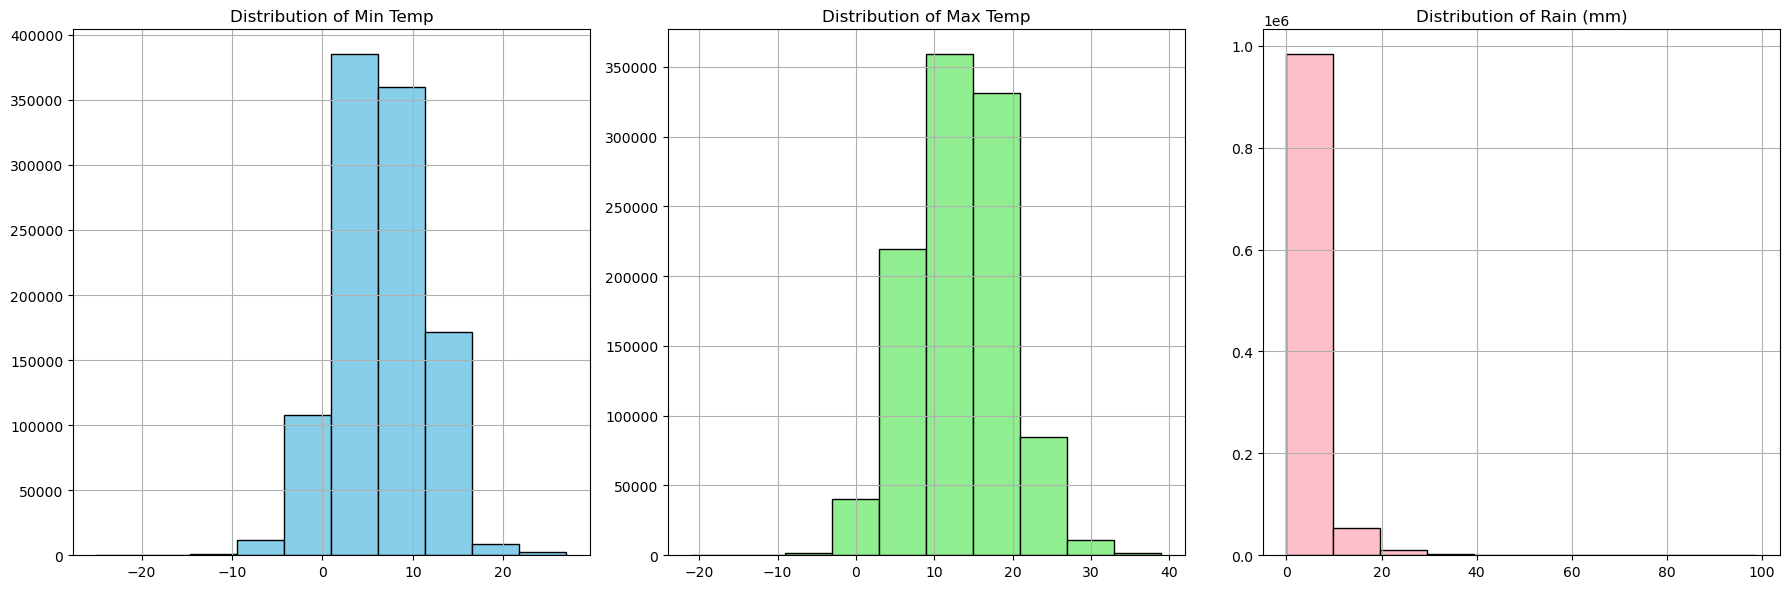

In [ ]:
# Creating three box plots to visualize the distrubution of the three numerical columns with null values

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

weather_df['min_temp_c'].hist(bins=10,ax=axes[0], edgecolor="black", color='skyblue')
axes[0].set_title("Distribution of Min Temp")

weather_df['max_temp_c'].hist(bins=10,ax=axes[1], edgecolor="black", color='lightgreen')
axes[1].set_title("Distribution of Max Temp")

weather_df['rain_mm'].hist(bins=10,ax=axes[2], edgecolor="black", color='pink')
axes[2].set_title("Distribution of Rain (mm)")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

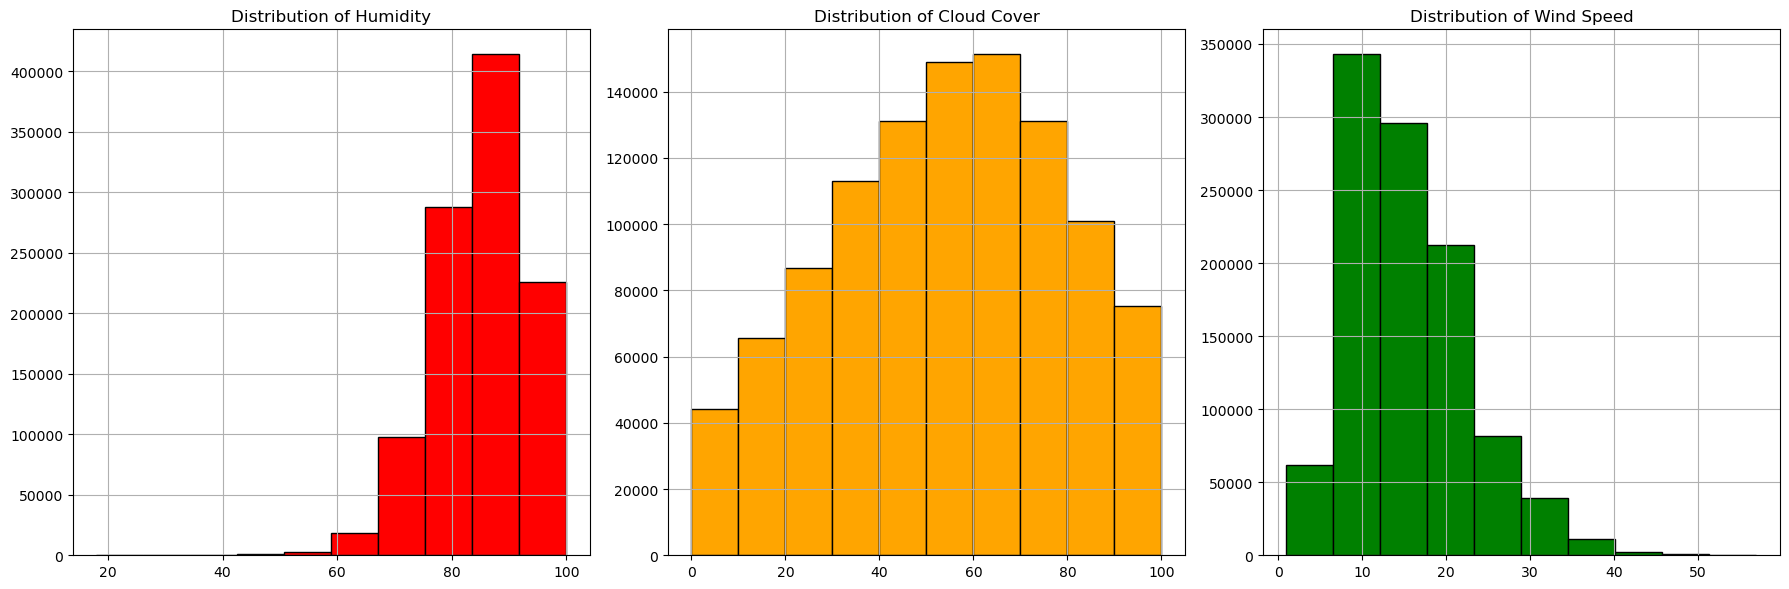

In [ ]:
# Creating three box plots to visualize the distrubution of the three numerical columns with null values

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

weather_df['humidity_pct'].hist(bins=10,ax=axes[0], edgecolor="black", color='red')
axes[0].set_title("Distribution of Humidity")

weather_df['cloud_cover_pct'].hist(bins=10,ax=axes[1], edgecolor="black", color='orange')
axes[1].set_title("Distribution of Cloud Cover")

weather_df['wind_speed_kmh'].hist(bins=10,ax=axes[2], edgecolor="black", color='green')
axes[2].set_title("Distribution of Wind Speed")

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

#### Boxplot

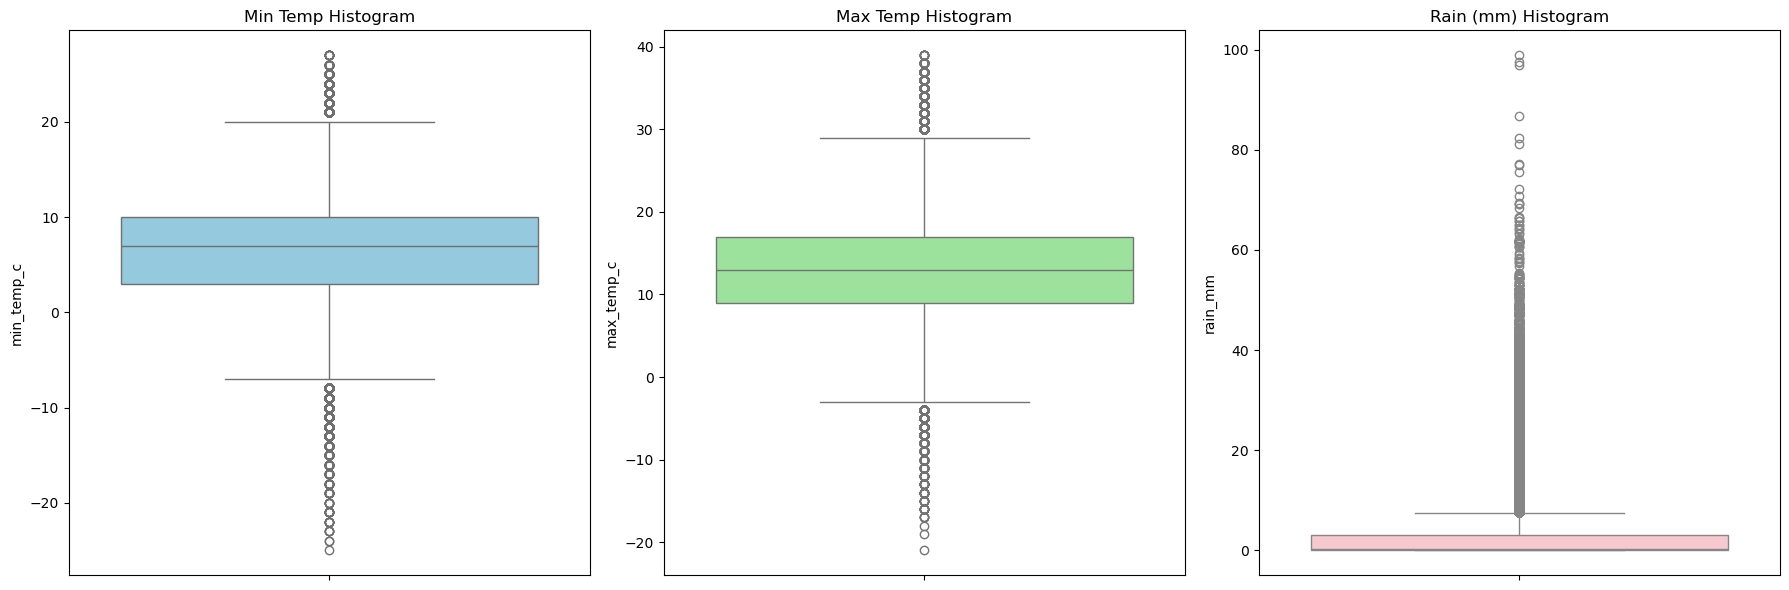

In [ ]:
# Creating three box plots to visualize the distrubution of the three numerical columns with null values

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=weather_df['min_temp_c'], ax=axes[0], color='skyblue')
axes[0].set_title('Min Temp Histogram')

sns.boxplot(y=weather_df['max_temp_c'], ax=axes[1], color='lightgreen')
axes[1].set_title('Max Temp Histogram')

sns.boxplot(y=weather_df['rain_mm'], ax=axes[2], color='pink')
axes[2].set_title('Rain (mm) Histogram')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

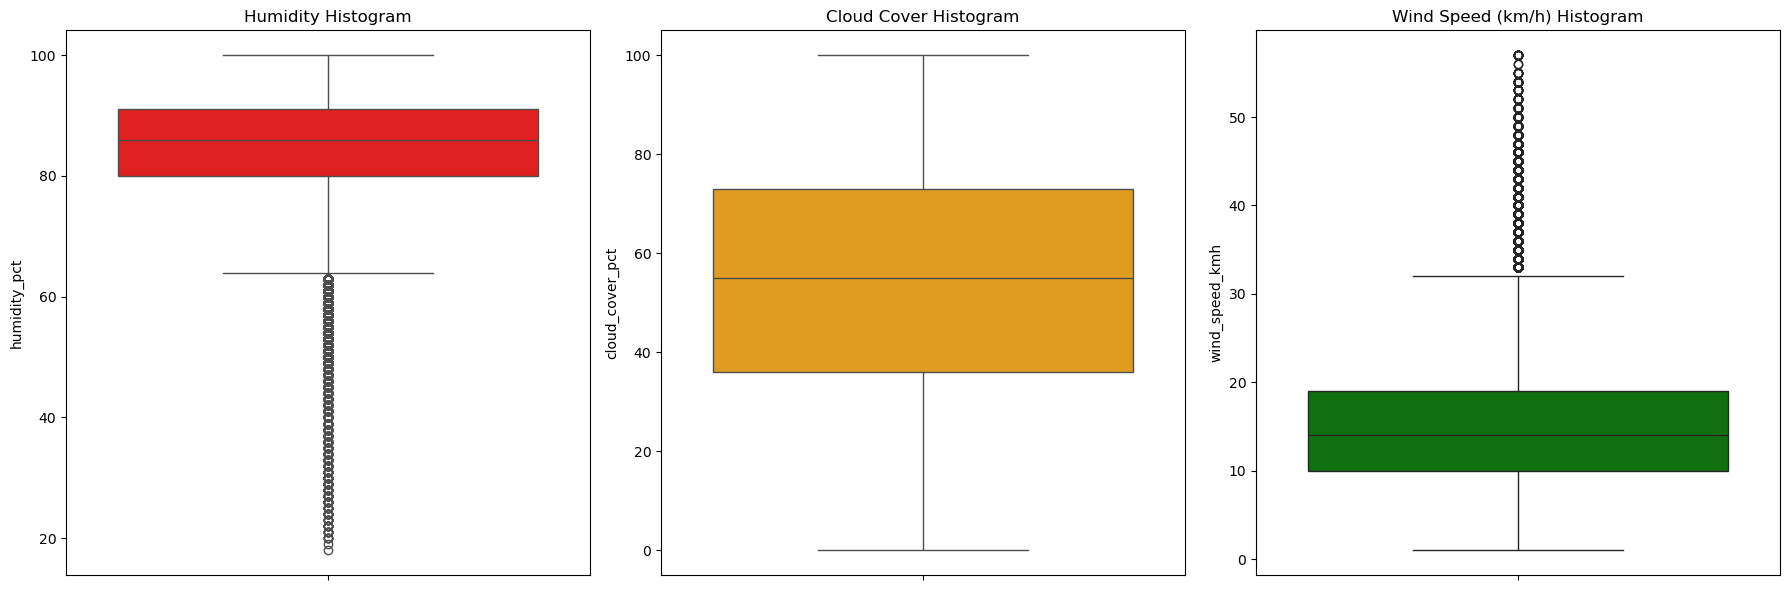

In [ ]:
# Creating three box plots to visualize the distrubution of the three numerical columns with null values

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=weather_df['humidity_pct'], ax=axes[0], color='red')
axes[0].set_title('Humidity Histogram')

sns.boxplot(y=weather_df['cloud_cover_pct'], ax=axes[1], color='orange')
axes[1].set_title('Cloud Cover Histogram')

sns.boxplot(y=weather_df['wind_speed_kmh'], ax=axes[2], color='green')
axes[2].set_title('Wind Speed (km/h) Histogram')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Minimum Temperature

The histogram is approximately normally distributed and centred around typical UK temperatures. The skewness (-0.16) is very close to zero, and the kurtosis is also close to zero. Although the boxplot identifies several outliers, these represent unusually cold or warm days rather than data errors. Since the distribution is approximately normal, the Z-score method is more appropriate for identifying unusually extreme observations.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Maximum Temperature

The maximum temperature also follows an approximately normal distribution. The skewness (0.08) is almost zero and the histogram appears fairly symmetric. Only a limited number of observations appear beyond the whiskers in the boxplot. Therefore, the Z-score method is appropriate for identifying unusually hot days.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Rainfall

Rainfall has a highly right-skewed distribution (skewness = 3.34) with extremely high kurtosis, indicating a long right tail and numerous extreme rainfall events. The histogram shows that most days receive little or no rainfall while a small number of days receive substantially higher rainfall amounts. Because the distribution is highly non-normal, the Interquartile Range (IQR) method is more appropriate than the Z-score method.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Humidity

Humidity shows moderate negative skewness (-0.82). Most observations fall between approximately 80% and 95%, with fewer observations at lower humidity levels. The boxplot identifies several lower-end outliers. Since the distribution is not normally distributed, the IQR method provides a more robust approach to detecting outliers.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Cloud Cover

Cloud cover is nearly symmetric with skewness close to zero (-0.16). The histogram resembles a fairly balanced distribution and the boxplot shows relatively few extreme observations. Consequently, the Z-score method is appropriate.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Wind Speed

Wind speed demonstrates moderate positive skewness (0.88). The histogram shows a noticeable right tail and the boxplot identifies several high-value observations. Since the distribution departs from normality, the IQR method is preferred.
</div>

#### Z-score variables

In [ ]:
from scipy.stats import zscore

weather_df["min_temp_z"] = zscore(weather_df["min_temp_c"])

min_temp_outliers = weather_df[
    weather_df["min_temp_z"].abs() > 3
]

print(min_temp_outliers.shape)

(4259, 14)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Z-Score method identified 4,259 outliers in the min temp variable. These min temp values are unusually high or low compared with most temperature values. Although they are outliers, they are likely to represent legitimate temperatures, such as extreme heat or cold events. As a result, these outliers will not be removed.
</div>

In [ ]:

weather_df["max_temp_z"] = zscore(weather_df["max_temp_c"])

max_temp_outliers = weather_df[
    weather_df["max_temp_z"].abs() > 3
]

print(max_temp_outliers.shape)

(4083, 14)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Z-Score method identified 4,083 outliers in the max temp variable. These max temp values are unusually high or low compared with most other temperatures. These outliers likely represent legitimate temperatures, such as extreme heat or cold events, and are therefore not removed.
</div>

In [ ]:
from scipy.stats import zscore

weather_df["cloud_cover_z"] = zscore(weather_df["cloud_cover_pct"])

cloud_outliers = weather_df[
    weather_df["cloud_cover_z"].abs() > 3
]

print(cloud_outliers.shape)

(0, 14)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Z-Score method identified 0 outliers in the cloud cover variable. This makes sense, as the cloud cover variable had a nearly symmetrical distribution, and nearly normal distribution.
</div>

#### IQR Variables

In [ ]:
Q1 = weather_df["rain_mm"].quantile(0.25)
Q3 = weather_df["rain_mm"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rain_outliers = weather_df[
    (weather_df["rain_mm"] < lower) |
    (weather_df["rain_mm"] > upper)
]

print(rain_outliers.shape)

(101917, 14)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The IQR method identified 101,917 outliers in the rain variable. These rain values are unusually high or low compared with most other rain amounts. These outliers are likely to represent legitimate rain events, such as thunderstorms or continuous rainstorms, and are therefore not removed.  
</div>

In [ ]:
Q1 = weather_df["humidity_pct"].quantile(0.25)
Q3 = weather_df["humidity_pct"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

humidity_outliers = weather_df[
    (weather_df["humidity_pct"] < lower) |
    (weather_df["humidity_pct"] > upper)
]

print(humidity_outliers.shape)

(9189, 14)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The IQR method identified 9,189 outliers in the humidity variable. These humidity values are unusually high or low compared with most other values. These outliers, however, are likely to represent legitimate high- or low-humidity days. As a result, these outliers will not be removed.
</div>

In [ ]:
Q1 = weather_df["wind_speed_kmh"].quantile(0.25)
Q3 = weather_df["wind_speed_kmh"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

wind_outliers = weather_df[
    (weather_df["wind_speed_kmh"] < lower) |
    (weather_df["wind_speed_kmh"] > upper)
]

print(wind_outliers.shape)

(23103, 14)


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The IQR method identified 23,103 outliers in the wind speed variable. These wind speed values are unusually high or low relative to the other values. These outliers are likely to represent legitimate wind speeds that could have occurred during storms and are therefore not removed.
</div>

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Weather conditions like heavy rainfall, heat waves, and strong winds are genuine weather phenomena rather than erroneous observations.

Because the objective of this project is to investigate how weather influences purchasing behaviour, these extreme weather conditions are potentially the most informative observations. Removing them could eliminate meaningful patterns from the analysis. For that reason, after detecting the outliers, we retained them in the dataset rather than removing them.
</div>

# Data Integration

## Aggregating Weather Data

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
Since the weather dataset represents weather across multiple cities and stations on a given date, not the whole UK, we will aggregate temperatures across cities for that date to find an average of UK temperature and weather on that date.
</div>

In [ ]:
daily_weather_df = (
    weather_df
    .groupby("weather_date")
    .agg(
        avg_min_temp_c=("min_temp_c", "mean"),
        avg_max_temp_c=("max_temp_c", "mean"),
        avg_rain_mm=("rain_mm", "mean"),
        avg_humidity_pct=("humidity_pct", "mean"),
        avg_cloud_cover_pct=("cloud_cover_pct", "mean"),
        avg_wind_speed_kmh=("wind_speed_kmh", "mean"),
        locations_reporting=("location", "nunique")
    )
    .reset_index()
)

In [ ]:
print("Daily weather shape:", daily_weather_df.shape)
print("Duplicate weather dates:",daily_weather_df["weather_date"].duplicated().sum())

daily_weather_df.head()

Daily weather shape: (2085, 8)
Duplicate weather dates: 0


,weather_date,avg_min_temp_c,avg_max_temp_c,avg_rain_mm,avg_humidity_pct,avg_cloud_cover_pct,avg_wind_speed_kmh,locations_reporting
0,2009-01-01,-1.988072,1.886680,0.114115,83.870775,32.479125,10.300199,503
1,2009-01-02,-0.705765,3.755467,0.046918,88.558648,43.236581,13.721670,503
2,2009-01-03,-2.089463,2.667992,0.102386,80.930417,25.284294,10.890656,503
3,2009-01-04,-2.043738,1.956262,0.517296,83.399602,58.314115,11.992048,503
4,2009-01-05,-1.789264,2.685885,0.772763,84.389662,37.079523,17.214712,503


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The weather data from each weather station was aggregated into a single daily record for each date. All columns in the weather_df were aggregated. The resulting aggregated dataset contains 2,085 rows, with no duplicate dates. This was done so that the data could be joined with the retail dataframe, which has rows with a date variable.
</div>

In [ ]:
# Create useful derived weather variables to add to the dataframe that might be used in the future to help answer our questions

# Avegage temp
daily_weather_df["avg_temp_c"] = (daily_weather_df["avg_min_temp_c"]+ daily_weather_df["avg_max_temp_c"]) / 2

In [ ]:
# Daily temperature range
daily_weather_df["temp_range_c"] = (daily_weather_df["avg_max_temp_c"]- daily_weather_df["avg_min_temp_c"])

In [ ]:
# Total sales amount
uk_fact_df_clean["line_sales_amount"] = (uk_fact_df_clean["quantity"]* uk_fact_df_clean["unit_price"])
uk_fact_df_clean.head()


,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount
0,1,489434,85048,United Kingdom,2009-12-01,07:45:00,12,6.95,83.4,83.4
1,2,489434,79323P,United Kingdom,2009-12-01,07:45:00,12,6.75,81.0,81.0
2,3,489434,79323W,United Kingdom,2009-12-01,07:45:00,12,6.75,81.0,81.0
3,4,489434,22041,United Kingdom,2009-12-01,07:45:00,48,2.10,100.8,100.8
4,5,489434,21232,United Kingdom,2009-12-01,07:45:00,24,1.25,30.0,30.0


## Join the tables

In [ ]:
# Convert invoice_time to string and remove the timedelta day component
uk_fact_df_clean["invoice_time"] = (
    uk_fact_df_clean["invoice_time"]
    .astype(str)
    .str.replace(r"^\d+\s+days?\s+", "", regex=True)
)

In [ ]:
# Join fact table with product dimension table
retail_weather_df = uk_fact_df_clean.merge(
    product_df_clean,
    on="product_code",
    how="left",
    validate="many_to_one"
)

In [ ]:
# Join the result with daily weather data
retail_weather_df = retail_weather_df.merge(
    daily_weather_df,
    left_on="invoice_date",
    right_on="weather_date",
    how="left",
    validate="many_to_one"
)

In [ ]:
# Remove redundant weather_date column (retaining invoice_date)
retail_weather_df = retail_weather_df.drop(columns=["weather_date"])

In [ ]:
# Validating the integration
print("Fact table rows before join:", len(uk_fact_df_clean))
print("Merged table rows after join:", len(retail_weather_df))

Fact table rows before join: 908912
Merged table rows after join: 908912


In [ ]:
retail_weather_df.head()

,sales_record_id,invoice_id,product_code,country,invoice_date,invoice_time,quantity,unit_price,total_amount,line_sales_amount,product_description,avg_min_temp_c,avg_max_temp_c,avg_rain_mm,avg_humidity_pct,avg_cloud_cover_pct,avg_wind_speed_kmh,locations_reporting,avg_temp_c,temp_range_c
0,1,489434,85048,United Kingdom,2009-12-01,07:45:00,12,6.95,83.4,83.4,15CM CHRISTMAS GLASS BALL 20 LIGHTS,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,503,3.416501,5.727634
1,2,489434,79323P,United Kingdom,2009-12-01,07:45:00,12,6.75,81.0,81.0,PINK CHERRY LIGHTS,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,503,3.416501,5.727634
2,3,489434,79323W,United Kingdom,2009-12-01,07:45:00,12,6.75,81.0,81.0,WHITE CHERRY LIGHTS,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,503,3.416501,5.727634
3,4,489434,22041,United Kingdom,2009-12-01,07:45:00,48,2.10,100.8,100.8,"RECORD FRAME 7"" SINGLE SIZE",0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,503,3.416501,5.727634
4,5,489434,21232,United Kingdom,2009-12-01,07:45:00,24,1.25,30.0,30.0,STRAWBERRY CERAMIC TRINKET BOX,0.552684,6.280318,3.22505,86.866799,55.787276,19.139165,503,3.416501,5.727634


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The weather dataset contained one observation per location per date, and the retail dataset contained multiple transaction lines per date. If the datasets were joined at their original grain, it would have resulted in duplicate retail observations for the hundreds of weather locations. That is why the weather data was aggregated to a national daily level. Mean values were calculated for temperature, rainfall, humidity, cloud cover, and wind speed, while the number of reporting locations and percentage of rainy locations were retained to provide additional context. The resulting daily weather dataframe contained one record per date and was joined to the UK retail transactions using a many-to-one left merge on the transaction date.
</div>

# Discretization

## Discretize Quanity Column

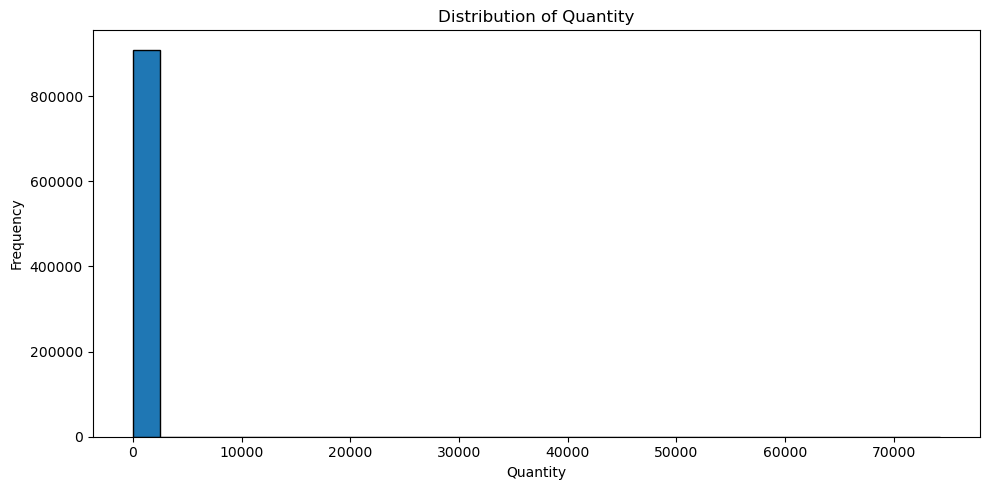

In [ ]:
# Plot the Distribution of the Quantity Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['quantity'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")
plt.tight_layout()
plt.show()

In [ ]:
print("Quantity skewness: ", retail_weather_df['quantity'].skew())

Quantity skewness:  576.9422109536974


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Quantity figure, the quantity variable is extremely positively skewed. This is corroborated by the skewness value of 576.94. This means that most transactions involve small quantities, with a small number involving extremely large quantities. Due to the extreme skewness, quantile binning will be used to discretize the variable into three bins. Quantile binning will create bins with approximately the same number of records in each.
</div>

In [ ]:
retail_weather_df["quantity_bin"], bin_edges = pd.qcut(
    retail_weather_df["quantity"],
    q=3,
    labels=["Low Quantity", "Medium Quantity", "High Quantity"],
    retbins=True,
    duplicates="drop"
)

print(bin_edges)

[1.0000e+00 2.0000e+00 6.0000e+00 7.4215e+04]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the quantity data using quantile binning, the three bins created are Low Quantity, Medium Quantity, and High Quantity. The resulting bin boundaries are 1-2, >2-6, and >6-74,215. These categories have around the same number of records.
</div>

## Discretize Date Column

In [ ]:
# Convert invoice_date to datetime type
retail_weather_df["invoice_date"] = pd.to_datetime(retail_weather_df["invoice_date"])

# Extract weekday names
retail_weather_df["day_name"] = retail_weather_df["invoice_date"].dt.day_name()

# Count transactions for each day and order Monday -> Sunday
day_counts = (retail_weather_df["day_name"].value_counts().reindex([
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday"]))


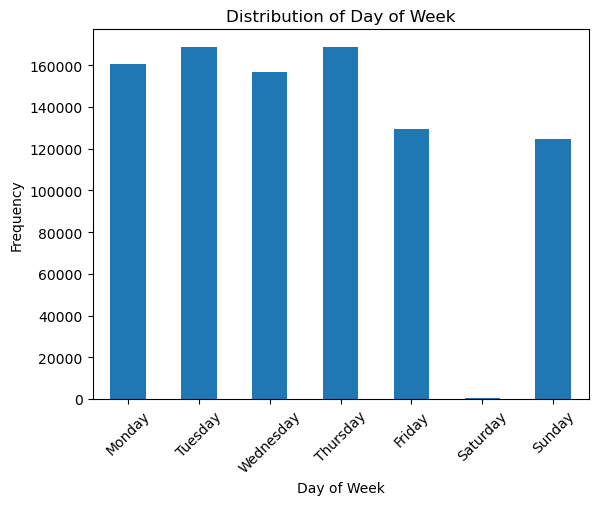

In [ ]:
day_counts.plot(kind="bar")
plt.title("Distribution of Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
retail_weather_df["day_type"] = retail_weather_df["day_name"].replace({
    "Monday": "Weekday",
    "Tuesday": "Weekday",
    "Wednesday": "Weekday",
    "Thursday": "Weekday",
    "Friday": "Weekday",
    "Saturday": "Weekend",
    "Sunday": "Weekend"
})

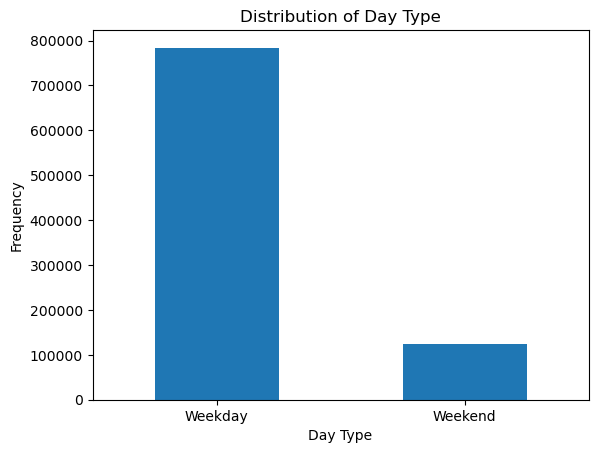

In [ ]:
# Count each day type in the correct order
day_type_counts = (
    retail_weather_df["day_type"]
    .value_counts()
    .reindex(["Weekday", "Weekend"])
)

# Plot
day_type_counts.plot(kind="bar")
plt.title("Distribution of Day Type")
plt.xlabel("Day Type")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The invoice_date column was discretized into two categorical variables. The first is the day of the week, Monday to Sunday. Thursday and Tuesday had the highest number of items bought, with Saturday having very little activity. The invoice_date was also binned into day types: Weekends (Saturday and Sunday) and Weekdays (Monday to Friday). The Distribution of Transactions by Day Type shows that most activity occurred on weekdays, with less activity occurring on weekends.
</div>

## Discretize Time Column

In [ ]:
# Convert to datetime
retail_weather_df["invoice_time"] = pd.to_datetime(
    retail_weather_df["invoice_time"],
    format="%H:%M:%S"
)

# Extract the hour
retail_weather_df["hour"] = retail_weather_df["invoice_time"].dt.hour

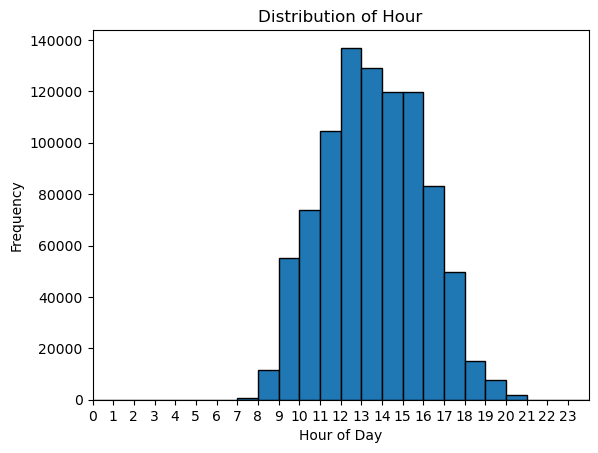

In [ ]:
plt.hist(retail_weather_df["hour"], bins=range(25), edgecolor="black")
plt.title("Distribution of Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.xticks(range(24))
plt.xlim(0, 24)

plt.show()

In [ ]:
# Discretize the data to custom bins based on day
retail_weather_df["time_bin"] = pd.cut(
    retail_weather_df["hour"],
    bins=[0, 12, 17, 24],
    labels=["Morning", "Afternoon", "Evening"],
    include_lowest=True,
    right=False
)

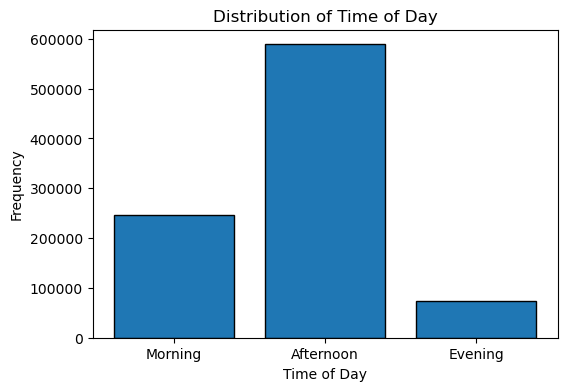

In [ ]:
# Count the number of transactions in each time bin
time_counts = retail_weather_df["time_bin"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(time_counts.index.astype(str), time_counts.values, edgecolor="black")
plt.title("Distribution of Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Frequency")
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The invoice_time variable was binned using two methods. The first is the hour of the day. The Distribution of Transactions by Hour figure shows that purchase activity starts around 8:00 AM, peaks around 12:00 PM, and declines during the evening. Next, the time was also discretized into the three time-of-day categories: Morning (8:00–11:59), Afternoon (12:00–16:59), and Evening (17:00–23:59). The Distribution of Time of Day plot shows that a majority of records occurred in the afternoon, with the morning having the next highest activity, and evening having the lowest activity.
</div>

## Discretize Unit Price Column

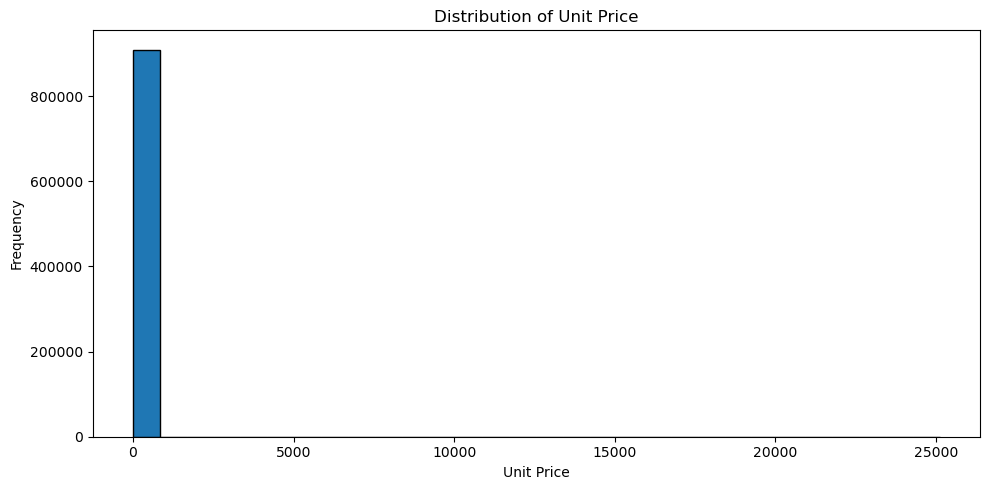

In [ ]:
# Plot the Distribution of the Unit Price Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['unit_price'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.title("Distribution of Unit Price")
plt.tight_layout()
plt.show()

In [ ]:
print("Unit Price skewness: ", retail_weather_df['unit_price'].skew())

Unit Price skewness:  256.0817867484106


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Unit Price figure, the unit price column is highly positively skewed, with a skewness of 256.081. This means that most transactions involve small unit prices, with a small number involving extremely large unit prices. Due to the extreme skewness, quantile binning will be used to discretize the variable into three bins. Quantile binning will create bins with approximately the same number of records in each.
</div>

In [ ]:
retail_weather_df["unit_price_bin"], bin_edges = pd.qcut(
    retail_weather_df["unit_price"],
    q=3,
    labels=["Low Unit Price", "Medium Unit Price", "High Unit Price"],
    retbins=True,
    duplicates="drop"
)

print(bin_edges)

[3.000000e-02 1.630000e+00 3.290000e+00 2.511109e+04]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the unit price data using quantile binning, the three bins created are "Low Unit Price", "Medium Unit Price", and "High Unit Price". The resulting bin boundaries are 0.03-1.63, >1.63-3.29, >3.29-25,11109. These categories have around the same number of records.
</div>

## Discretize Avg Min Temp C Column

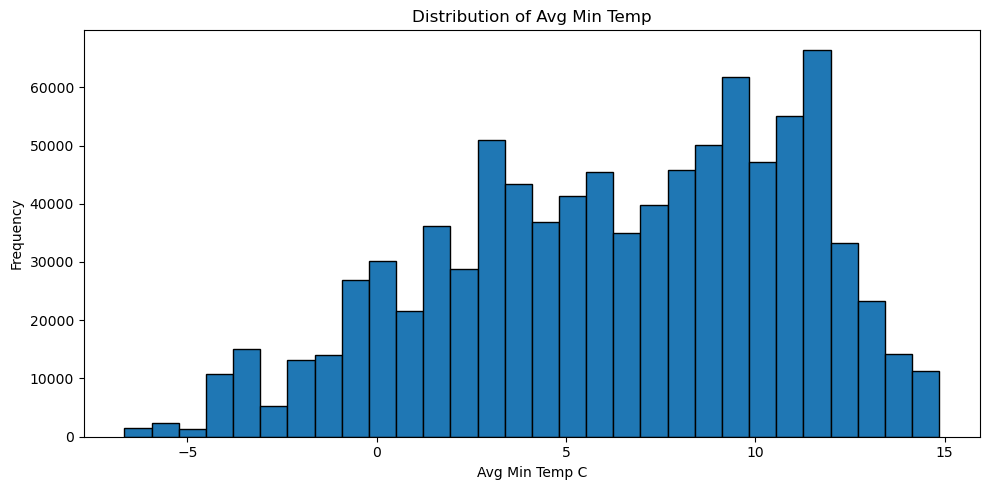

In [ ]:
# Plot the Distribution of the Avg Min Temp C Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_min_temp_c'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Min Temp C")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Min Temp")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Min Temp C skewness: ", retail_weather_df['avg_min_temp_c'].skew())

Avg Min Temp C skewness:  -0.37729136736844915


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Min Temp figure, the average min temp variable is almost symmetric, with a skewness value of -0.37. This means that values are evenly distributed across the range. Due to this almost symmetry, equal-width binning will be used to discretize the variable into three bins. Equal-width binning will create bins with approximately equal numerical ranges.
</div>

In [ ]:
retail_weather_df["avg_min_temp_c_bin"], bin_edges = pd.qcut(
    retail_weather_df["avg_min_temp_c"],
    q=3,
    labels=["Low Average Minimum Temperature", "Medium Average Minimum Temperature", "High Average Minimum Temperature"],
    retbins=True,
    duplicates="drop"
)

print(bin_edges)

[-6.66003976  4.13121272  9.22266402 14.85685885]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Min Temp C variable, the three bins created are "Low Average Minimum Temperature", "Medium Average Minimum Temperature", and "High Average Minimum Temperature". The bin boundaries are -6.66-4.13, >4.13-9.22, >9.22-14.86. These categories are around the same width.
</div>

## Discretize Avg Min Temp C Column

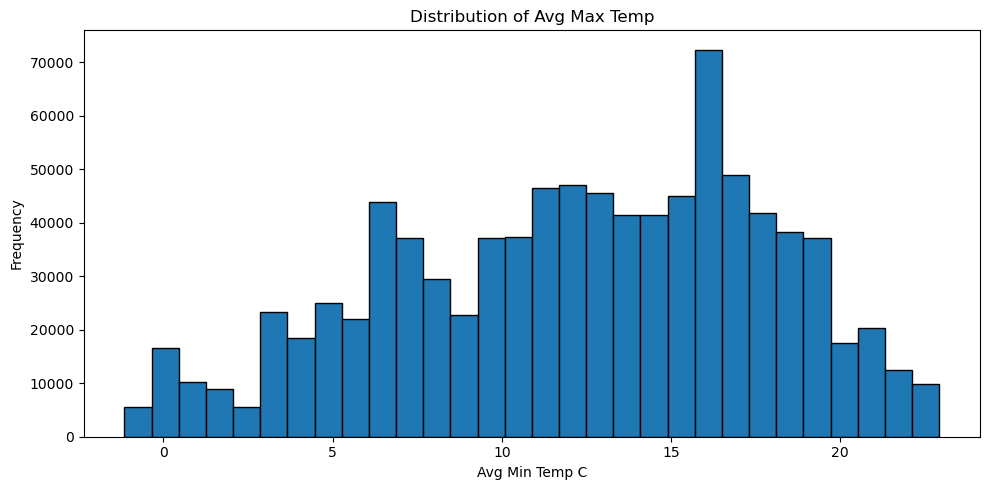

In [ ]:
# Plot the Distribution of the Avg Max Temp C Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_max_temp_c'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Min Temp C")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Max Temp")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Max Temp C skewness: ", retail_weather_df['avg_max_temp_c'].skew())

Avg Max Temp C skewness:  -0.33888833760725756


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Max Temp figure, the average max temp variable is almost symmetric, with a skewness of -0.33. This means that values are almost evenly distributed across the range. Due to this almost symmetry, equal-width binning will be used to discretize the variable into three bins. Equal-width binning will create bins with approximately equal numerical ranges.
</div>

In [ ]:
retail_weather_df["avg_max_temp_c_bin"], bin_edges = pd.qcut(
    retail_weather_df["avg_max_temp_c"],
    q=3,
    labels=["Low Average Maximum Temperature", "Medium Average Maximum Temperature", "High Average Maximum Temperature"],
    retbins=True,
    duplicates="drop"
)

print(bin_edges)

[-1.15506958  9.972167   15.65805169 22.92842942]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Max Temp variable, the three bins created are "Low Average Maximum Temperature", "Medium Average Maximum Temperature", and "High Average Maximum Temperature". The resulting bin boundaries are -1.15-9.97, >9.97-15.65, >15.65-22.93. These categories are around the same width.
</div>

## Discretize Avg Rain mm Column

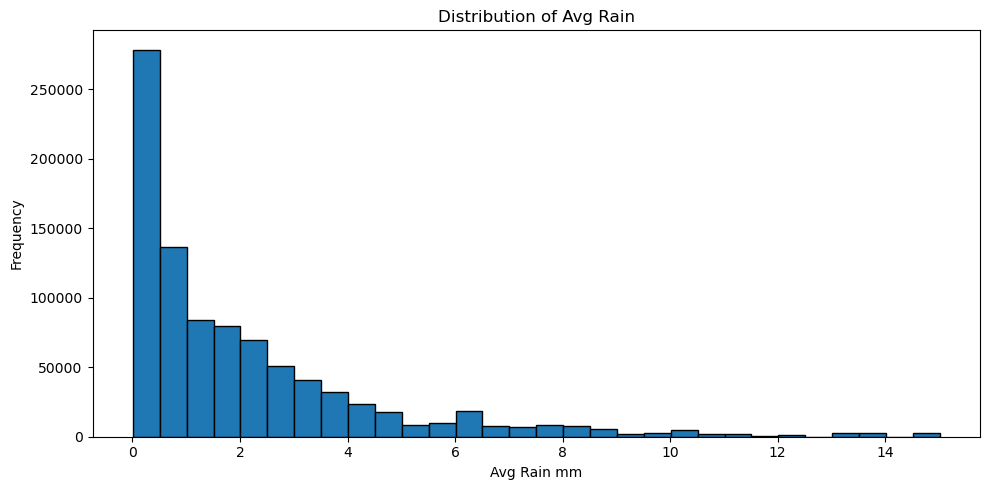

In [ ]:
# Plot the Distribution of the Avg Rain mm Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_rain_mm'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Rain mm")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Rain")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Rain mm skewness: ", retail_weather_df['avg_rain_mm'].skew())

Avg Rain mm skewness:  2.1175282448780726


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Rain figure, the Avg Rain variable is positively skewed. This is corroborated by the skewness value of 2.11. This means that most transactions involve low temperatures, with a small number involving larger temperatures. Due to the extreme skewness, quantile binning will be used to discretize the variable into three bins. Quantile binning will create bins with approximately the same number of records in each.
</div>

In [ ]:
retail_weather_df["avg_rain_bin"], bin_edges = pd.qcut(
    retail_weather_df["avg_rain_mm"],
    q=3,
    labels=["Low Rainfall","Medium Rainfall","High Rainfall"],
    retbins=True,
    duplicates="drop"
)

print(bin_edges)

[9.14512922e-03 5.84095427e-01 2.21908549e+00 1.50101392e+01]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Rain variable, the three bins created are "Low Rainfall", "Medium Rainfall", and "High Rainfall". The resulting bin boundaries are 0.009-0.584, >0.584-2.21, >2.21-15,010. These categories have around the same number of transactions.
</div>

## Discretize Avg Humidity Column

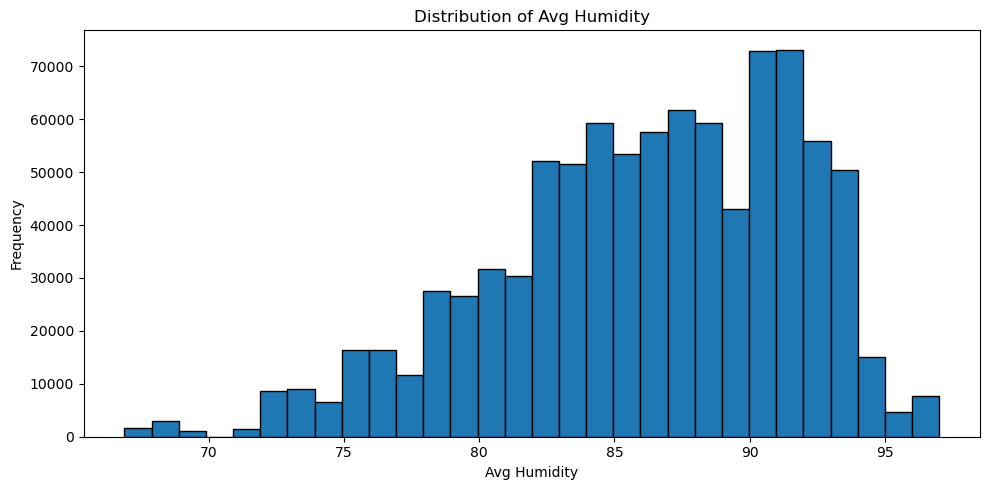

In [ ]:
# Plot the Distribution of the Avg Humidity Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_humidity_pct'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Humidity")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Humidity")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Humidity skewness: ", retail_weather_df['avg_humidity_pct'].skew())

Avg Humidity skewness:  -0.5782890401691312


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Humidity figure, the Avg Humidity variable is moderately negatively skewed (-0.57). This means that there are slightly more higher values, with a few lower humidity values. Due to the skewness, quantile binning will be used to discretize the variable into three bins. Quantile binning will create bins with approximately the same number of records in each.
</div>

In [ ]:
retail_weather_df["avg_humidity_bin"], bin_edges = pd.qcut(
    retail_weather_df["avg_humidity_pct"],
    q=3,
    labels=["Low Humidity","Medium Humidity","High Humidity"],
    retbins=True,
    duplicates="drop"
)

print(bin_edges)

[66.86481113 84.13518887 89.58928571 97.01789264]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Humidity variable using quantile binning, the three bins created are "Low Humidity", "Medium Humidity", and "High Humidity". The resulting bin boundaries are 66.86-84.13, >84.13-89.58, and >89.58-97.02. These categories have around the same number of records
</div>

## Discretize Avg Cloud Cover Column

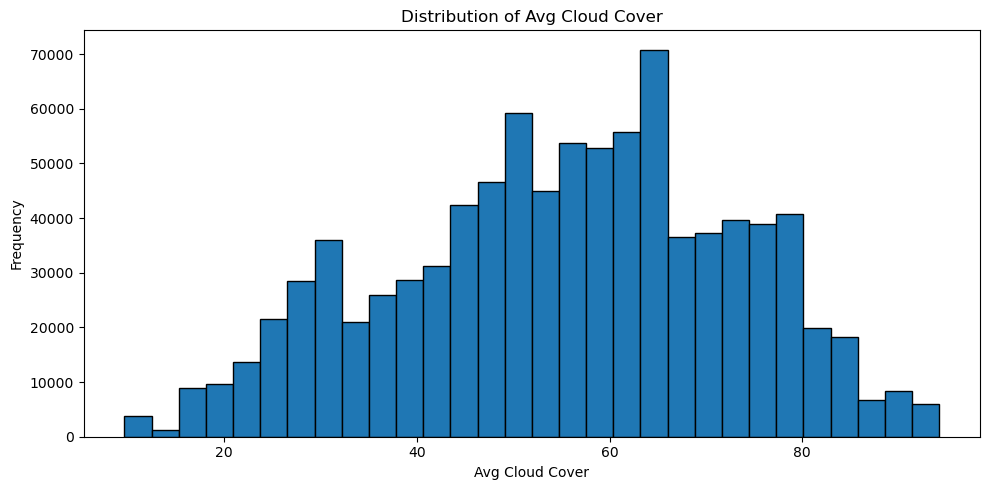

In [ ]:
# Plot the Distribution of the Avg Cloud Cover Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_cloud_cover_pct'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Cloud Cover")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Cloud Cover")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Cloud Cover skewness: ", retail_weather_df['avg_cloud_cover_pct'].skew())

Avg Cloud Cover skewness:  -0.21655875756664955


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Cloud Cover, the average cloud cover variable is almost symmetric. This means that values are nearly evenly distributed across the range.  Due to this almost symmetry, equal-width binning will be used to discretize the variable into three bins. Equal-width binning will create bins with approximately equal numerical ranges.
</div>

In [ ]:
retail_weather_df["avg_cloud_cover_bin"], bin_edges = pd.cut(
    retail_weather_df["avg_cloud_cover_pct"],
    bins=3,
    labels=["Low Cloud Cover","Medium Cloud Cover","High Cloud Cover"],
    retbins=True
)

print(bin_edges)

[ 9.58145726 37.84824387 66.03048376 94.21272366]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Cloud Cover variable, the three bins created are "Low Cloud Cover", "Medium Cloud Cover", and "High Cloud Cover". The bin boundaries are 9.58-37.85, >37.85-66.03, >66.03-94.21. These categories are around the same width.
</div>

## Discretize Avg Wind Speed Column

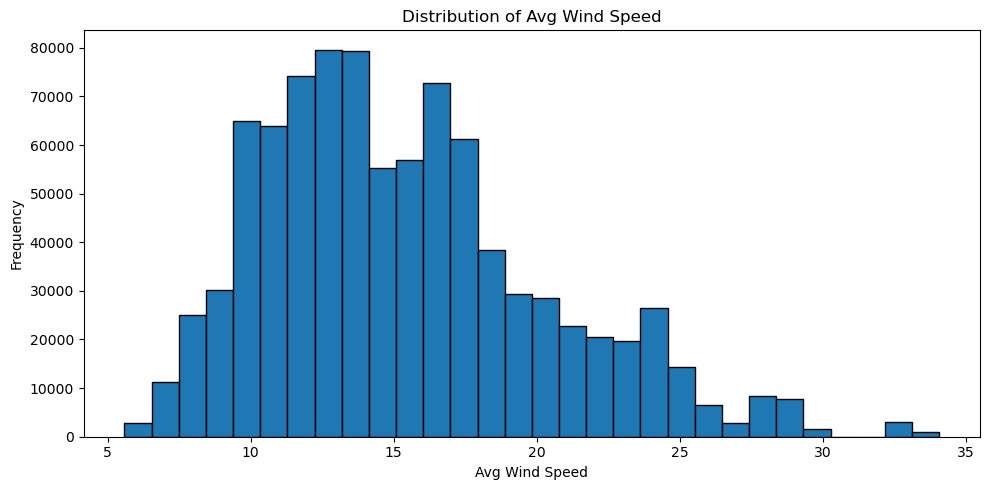

In [ ]:
# Plot the Distribution of the Avg Cloud Cover Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_wind_speed_kmh'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Wind Speed")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Wind Speed")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Wind Speed skewness: ", retail_weather_df['avg_wind_speed_kmh'].skew())

Avg Wind Speed skewness:  0.7581605415810067


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Wind Speed figure, the average wind speed variable is slightly positively skewed. This means that more records involve low wind speeds, with a few wind speeds that are much higher. Due to the skewness, quantile binning will be used to discretize the variable into three bins. Quantile binning will create bins with approximately the same number of records in each.
</div>

In [ ]:
retail_weather_df["avg_wind_speed_bin"], bin_edges = pd.cut(
    retail_weather_df["avg_wind_speed_kmh"],
    bins=3,
    labels=["Low Wind Speed","Medium Wind Speed","High Wind Speed"],
    retbins=True
)

print(bin_edges)

[ 5.55800398 15.07886017 24.57123923 34.06361829]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Wind Speed variable using quantile binning, the three bins created are "Low Wind Speed", "Medium Wind Speed", and "High Wind Speed". The resulting bin boundaries are 5.56-15.09, >15.09-24.57, >24.57-34.06. These categories have around the same number of transactions.
</div>

## Discretize Avg Temp Column

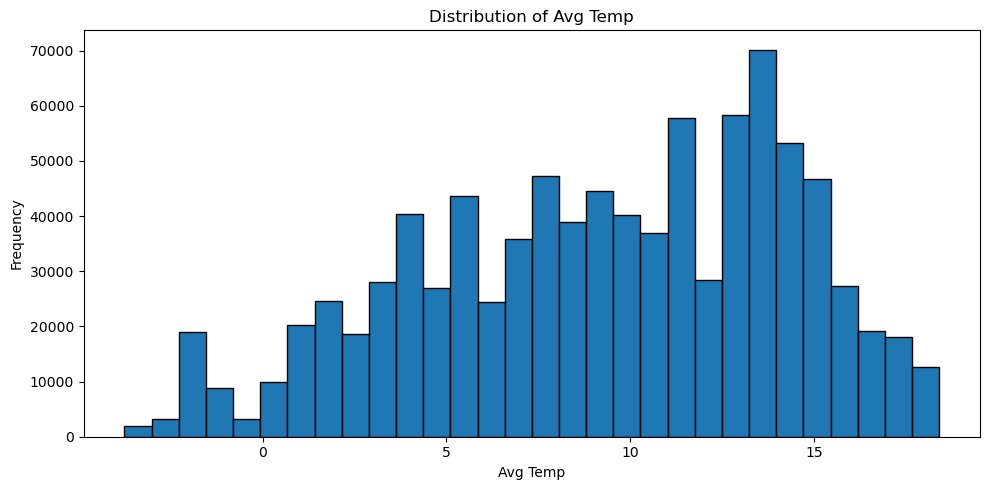

In [ ]:
# Plot the Distribution of the Avg Temp Column
plt.figure(figsize=(10, 5))
plt.hist(retail_weather_df['avg_temp_c'].dropna(),bins=30,edgecolor="black")
plt.xlabel("Avg Temp")
plt.ylabel("Frequency")
plt.title("Distribution of Avg Temp")
plt.tight_layout()
plt.show()

In [ ]:
print("Avg Temp skewness: ", retail_weather_df['avg_temp_c'].skew())

Avg Temp skewness:  -0.3876139176159293


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As seen in the Distribution of Avg Temp figure, the average temp variable is almost symmetric, with a slight negative skew of -0.36. This means that values are evenly distributed across the range. Due to this almost symmetry, equal-width binning will be used to discretize the variable into three bins. Equal-width binning will create bins with approximately equal numerical ranges.
</div>

In [ ]:
retail_weather_df["avg_temp_bin"], bin_edges = pd.cut(
    retail_weather_df["avg_temp_c"],
    bins=3,
    labels=["Low Avg Temp","Medium Avg Temp","High Avg Temp"],
    retbins=True
)

print(bin_edges)

[-3.77762525  3.63055003 11.01656726 18.40258449]


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
After discretizing the Avg Temp variable, the three bins created are "Low Avg Temp", "Medium Avg Temp", and "High Avg Temp". The bin boundaries are -3.77-3.63, >3.63-11.02, >11.02-18.4. These categories are around the same width.
</div>

## Discretize Temp Range Column

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Temp Range variable will not be discretized. This variable is a derived value obtained by subtracting avg_min_temp_c from avg_max_temp_c. Since the minimum and maximum average temperatures already capture the important information, discretizing the range would only add redundant information. Additionally, since the goal of the project is to analyze the relationship between purchasing behaviour and the weather, the daily temperature range will not provide useful information beyond what is already available in the minimum and maximum average temperatures.
</div>

## Discretize Total Sales Amount Column

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
The Total Sales Amount variable will not be discretized. This variable is a derived value obtained by multiplying the quantity and unit price. Since the quantity and unit price already capture the important information, discretizing the Line Sales Amount would only add redundant information. Additionally, since the goal of the project is to analyze the relationship between purchasing behaviour and the weather, the Line Sales Amount will not provide useful information beyond what is already available in the quantity and unit price.
</div>